**MERGED DATASET ANALİZİ (EDA PIPELINE)**

In [7]:

import pandas as pd
df = pd.read_parquet("../data/merged/merged_dataset.parquet")
print(df.columns)

Index(['user_id', 'item_id', 'rating', 'review_text', 'price', 'category',
       'timestamp', 'review_date'],
      dtype='object')



1.Amaç 
Dataset'in boyutunu anlamak

In [29]:
print("Satır sayısı:", len(df))
print("Kullanıcı sayısı:", df["user_id"].nunique())
print("Ürün sayısı:", df["item_id"].nunique())

Satır sayısı: 1075433
Kullanıcı sayısı: 900839
Ürün sayısı: 190900


🔥 2. SPARSITY (EN KRİTİK METRİK)

In [30]:
num_users = df["user_id"].nunique()
num_items = df["item_id"].nunique()
num_interactions = len(df)

sparsity = 1 - (num_interactions / (num_users * num_items))

print("Sparsity:", sparsity)

Sparsity: 0.9999937463978164


👥 3. USER INTERACTION ANALİZİ

In [31]:
user_counts = df["user_id"].value_counts()

print(user_counts.describe())

count    900839.000000
mean          1.193813
std           0.995755
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         189.000000
Name: count, dtype: float64


📦 4. ITEM POPULARITY

In [32]:
item_counts = df["item_id"].value_counts()

print(item_counts.describe())

count    190900.000000
mean          5.633489
std           4.196320
min           1.000000
25%           2.000000
50%           4.000000
75%           9.000000
max          15.000000
Name: count, dtype: float64


⭐ 5. RATING DAĞILIMI

In [33]:
print(df["rating"].value_counts())

rating
5    730794
4    117182
1    104507
3     73760
2     49190
Name: count, dtype: int64


🧾 6. TEXT ANALİZİ

In [34]:
df["text_len"] = df["review_text"].astype(str).apply(lambda x: len(x.split()))

print(df["text_len"].describe())

count    1.075433e+06
mean     3.422382e+01
std      4.954037e+01
min      0.000000e+00
25%      8.000000e+00
50%      2.000000e+01
75%      4.100000e+01
max      5.660000e+03
Name: text_len, dtype: float64


💰 7. PRICE ANALİZİ

In [35]:
print(df["price"].describe())

count    1.075433e+06
mean     3.793822e+01
std      1.010330e+02
min      1.000000e-02
25%      1.159000e+01
50%      1.865000e+01
75%      3.299000e+01
max      1.900000e+04
Name: price, dtype: float64


⏱️ 8. ZAMAN ANALİZİ
📊 Yorum
veri ne kadar eski?
trend var mı?

In [36]:
print(df["timestamp"].min(), df["timestamp"].max())

2000-05-09 22:54:34 2023-09-12 18:18:54.540000



🔁 9. DUPLICATE KONTROL

In [37]:
print("Duplicate:", df.duplicated().sum())

Duplicate: 5939


❗ 10. NULL ANALİZİ

In [38]:
print(df.isnull().mean())

user_id        0.0
item_id        0.0
rating         0.0
review_text    0.0
price          0.0
category       0.0
timestamp      0.0
review_date    0.0
text_len       0.0
dtype: float64


📊 11. COVERAGE

In [39]:
print("User coverage:", df["user_id"].nunique())
print("Item coverage:", df["item_id"].nunique())

User coverage: 900839
Item coverage: 190900


🎯 BONUS: GRAFİK

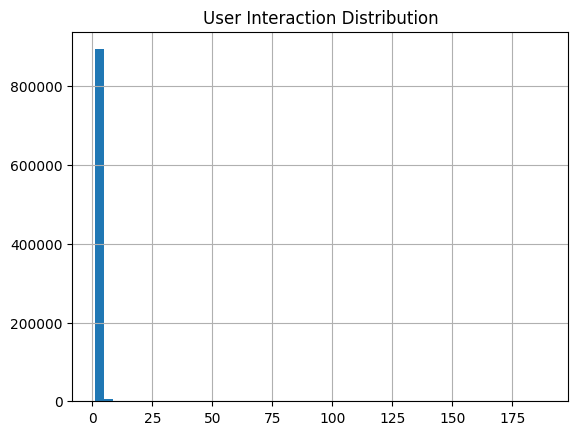

In [40]:
import matplotlib.pyplot as plt

user_counts.hist(bins=50)
plt.title("User Interaction Distribution")
plt.show()